(144, 2)
     month  total_passengers
0  1949-01               112
1  1949-02               118
2  1949-03               132
3  1949-04               129
4  1949-05               121
month               object
total_passengers     int64
dtype: object
month               datetime64[ns]
total_passengers             int64
dtype: object
            total_passengers
month                       
1960-10-01               461
1960-11-01               390
1960-12-01               432
            total_passengers
month                       
1949-08-01               148
1956-06-01               374
1957-02-01               301
1951-03-01               178
1958-03-01               362
            total_passengers
month                       
1950-01-01               115
1950-02-01               126
1950-03-01               141
1950-04-01               135
1950-05-01               125
1950-06-01               149
1950-07-01               170
1950-08-01               170
1950-09-01               15

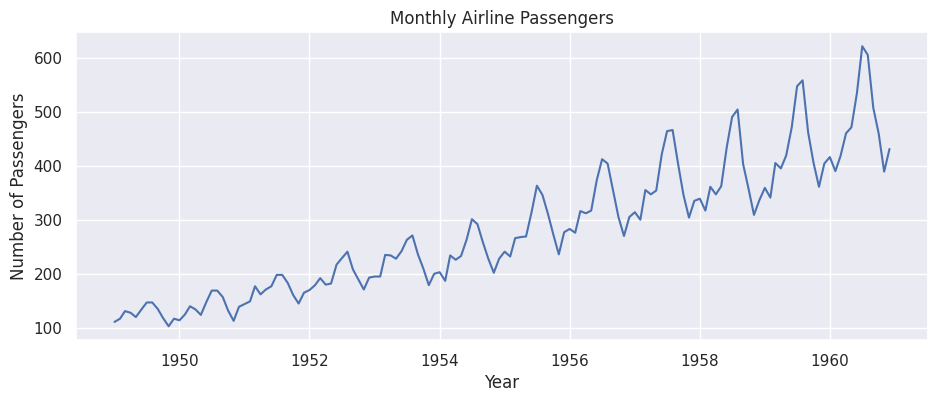

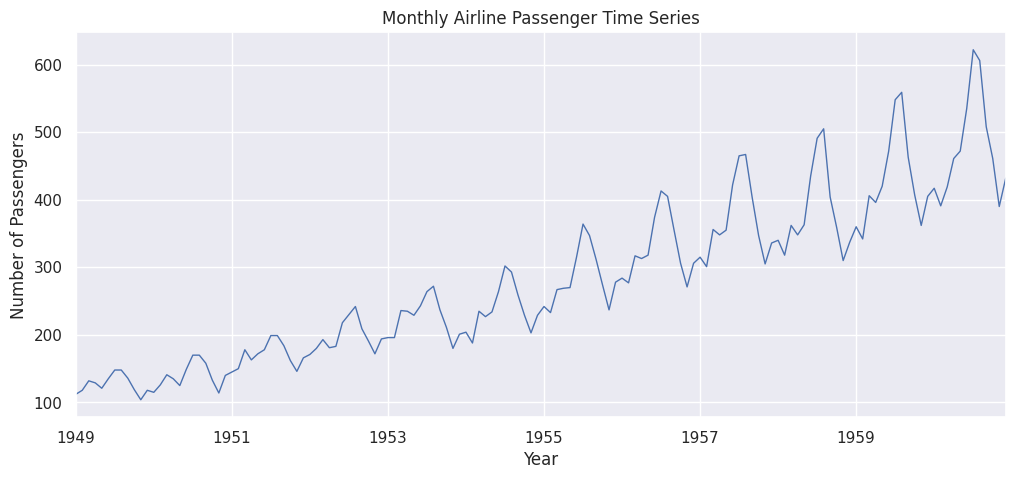

            total_passengers  Cumulative_Passengers
month                                              
1949-01-01               112                    112
1949-02-01               118                    230
1949-03-01               132                    362
1949-04-01               129                    491
1949-05-01               121                    612


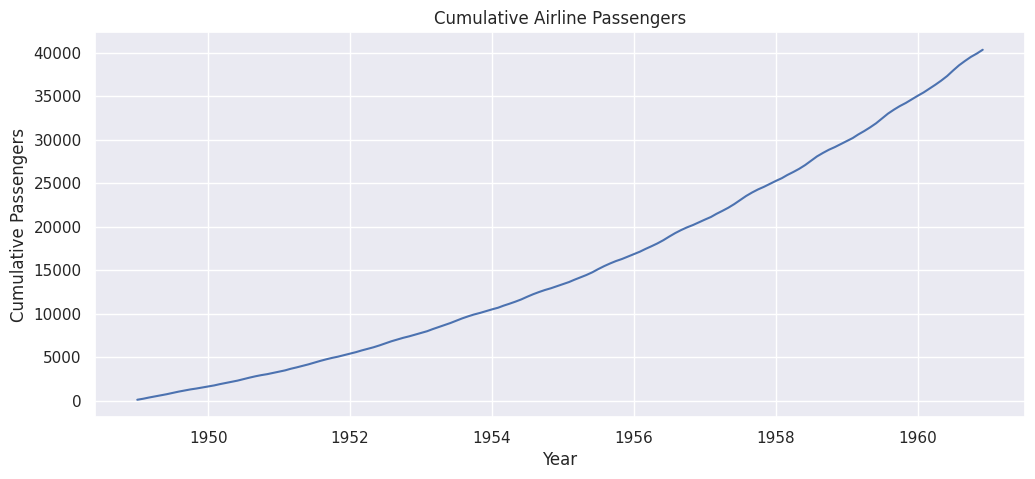

month
1949-12-31    126.666667
1950-12-31    139.666667
1951-12-31    170.166667
1952-12-31    197.000000
1953-12-31    225.000000
1954-12-31    238.916667
1955-12-31    284.000000
1956-12-31    328.250000
1957-12-31    368.416667
1958-12-31    381.000000
1959-12-31    428.333333
1960-12-31    476.166667
Freq: YE-DEC, Name: total_passengers, dtype: float64


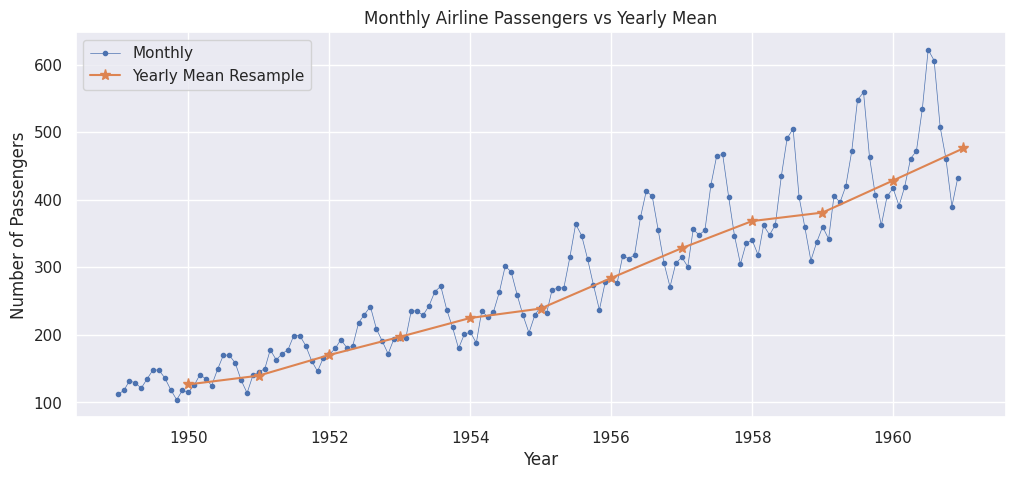

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Generate and load dataset
df_airline = pd.read_csv("airline-passengers.csv")

# Check shape of dataset
print(df_airline.shape)

# Check few entries
print(df_airline.head())

# Check data types
print(df_airline.dtypes)

# Convert Month column to datetime
df_airline['month'] = pd.to_datetime(df_airline['month'])

# Check data types after conversion
print(df_airline.dtypes)

# Change index to Month column
df_airline = df_airline.set_index('month')

# Display last 3 rows
print(df_airline.tail(3))

# Display random sampling of 5 rows
print(df_airline.sample(5, random_state=0))

# Time-based indexing
print(df_airline.loc['1950'])
print(df_airline.loc['1950-01'])
print(df_airline.loc['1950-01':'1951-12'])

# Plot time series using Seaborn
sns.set(rc={'figure.figsize': (11, 4)})

sns.lineplot(
    data=df_airline,
    x=df_airline.index,
    y='total_passengers'
)

plt.title('Monthly Airline Passengers')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.show()

# Plot time series using Pandas
ax = df_airline['total_passengers'].plot(
    linewidth=1,
    figsize=(12, 5)
)

ax.set_title('Monthly Airline Passenger Time Series')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Passengers')
plt.show()

# Generate cumulative sum
df_airline['Cumulative_Passengers'] = df_airline['total_passengers'].cumsum()

# Display cumulative sum
print(df_airline.head())

# Plot cumulative sum using Seaborn
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=df_airline,
    x=df_airline.index,
    y='Cumulative_Passengers'
)

plt.title('Cumulative Airline Passengers')
plt.xlabel('Year')
plt.ylabel('Cumulative Passengers')
plt.show()

# Resample data yearly
yearly_mean = df_airline['total_passengers'].resample('YE').mean()

# Display yearly mean
print(yearly_mean)

# Plot monthly data and yearly mean
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    df_airline['total_passengers'],
    marker='.',
    linestyle='-',
    linewidth=0.5,
    label='Monthly'
)

ax.plot(
    yearly_mean,
    marker='*',
    markersize=8,
    linestyle='-',
    label='Yearly Mean Resample'
)

ax.set_ylabel('Number of Passengers')
ax.set_xlabel('Year')
ax.set_title('Monthly Airline Passengers vs Yearly Mean')
ax.legend()

plt.show()
